# Random Search Hyperparameter Tuning
**Models:** SGDClassifier vs LogisticRegression  
**Method:** RandomizedSearchCV  
**Objective:** Maximize F1 score (Toxic class)

In [1]:
""" import sys
!{sys.executable} -m pip install -r ../requirement.txt """

' import sys\n!{sys.executable} -m pip install -r ../requirement.txt '

## Step 1: Imports

In [2]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import hstack, csr_matrix
from scipy.stats import loguniform, uniform

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, RandomizedSearchCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, f1_score,
    roc_auc_score, ConfusionMatrixDisplay
)

from toxic_pipeline import (
    ALL_ENGINEERED_FEATURE_COLUMNS,
    WORD_TFIDF_CONFIG as PIPELINE_WORD_TFIDF_CONFIG,
    build_all_engineered_features,
    clean_text,
    protect_non_toxic_negations,
)

print('All imports OK')


All imports OK


## Step 1.5: Constants


In [3]:
DATA_PATH = '../data/train.csv'
LABEL_COLUMNS_TO_DROP = ['severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

SEARCH_RANDOM_STATE = 42
SEARCH_TEST_SIZE = 0.20
SEARCH_CV_SPLITS = 3
RANDOM_SEARCH_ITERATIONS = 20
SEARCH_CLASS_WEIGHTS = ['balanced', {0:1,1:3}]

WORD_TFIDF_CONFIG = dict(PIPELINE_WORD_TFIDF_CONFIG)
SCALER_CONFIG = {'with_mean': False}
SGD_FIXED_MAX_ITER = 500
LR_FIXED_MAX_ITER = 500

SGD_BASELINE_CONFIG = {
    'loss': 'modified_huber',
    'class_weight': 'balanced',
    'max_iter': SGD_FIXED_MAX_ITER,
    'tol': 1e-4,
    'random_state': SEARCH_RANDOM_STATE,
    'n_jobs': None,
}
LR_BASELINE_CONFIG = {
    'solver': 'liblinear',
    'penalty': 'l2',
    'C': 1.0,
    'tol': 1e-4,
    'class_weight': 'balanced',
    'max_iter': LR_FIXED_MAX_ITER,
    'random_state': SEARCH_RANDOM_STATE,
    'n_jobs': None,
}

SGD_RANDOM_SEARCH_PARAM_DIST = {
    'alpha': loguniform(1e-5, 1e-3),
    'penalty': ['l2', 'l1', 'elasticnet'],
    'class_weight': SEARCH_CLASS_WEIGHTS,
    'max_iter': [SGD_FIXED_MAX_ITER],
    'tol': loguniform(1e-5, 1e-3),
    'l1_ratio': uniform(0.05, 0.90),
}
LR_RANDOM_SEARCH_PARAM_DIST = {
    'C': loguniform(3e-2, 3.0),
    'class_weight': SEARCH_CLASS_WEIGHTS,
    'solver': ['liblinear', 'saga'],
    'penalty': ['l2', 'l1'],
    'tol': loguniform(1e-5, 1e-3),
}
LR_TUNED_MODEL_CONFIG = {
    'max_iter': LR_FIXED_MAX_ITER,
    'random_state': SEARCH_RANDOM_STATE,
    'n_jobs': None,
}

RANDOM_SEARCH_WORD_VECTORIZER_PATH = 'random_search_word_vectorizer.pkl'
RANDOM_SEARCH_SCALER_PATH = 'random_search_scaler.pkl'
RANDOM_SEARCH_BEST_MODEL_PATH = 'random_search_best_model.pkl'


## Step 2: Load & Clean Data

In [4]:
df = pd.read_csv(DATA_PATH)
df = df.drop(columns=LABEL_COLUMNS_TO_DROP)

df['raw_text'] = df['comment_text'].fillna('').astype(str)
df['protected_text'] = df['raw_text'].apply(protect_non_toxic_negations)
df['clean_text'] = df['protected_text'].apply(clean_text)
df = df[df['clean_text'] != ''].copy()
df = df.drop_duplicates(subset=['clean_text']).reset_index(drop=True)

print(f'Dataset shape (sampled): {df.shape}')
print(df['toxic'].value_counts())


Dataset shape (sampled): (158194, 6)
toxic
0    143038
1     15156
Name: count, dtype: int64


## Step 3: Feature Engineering

In [5]:
engineered_df = pd.concat(
    [build_all_engineered_features(text) for text in df['raw_text']],
    ignore_index=True,
)
df[ALL_ENGINEERED_FEATURE_COLUMNS] = engineered_df

print('Feature engineering done')


Feature engineering done


## Step 4: Train/Test Split & Vectorize

In [6]:
ENG_FEATURE_COLS = ALL_ENGINEERED_FEATURE_COLUMNS.copy()

X_clean = df['clean_text']
X_eng = df[ENG_FEATURE_COLS]
y = df['toxic']

(
    X_clean_train, X_clean_test,
    X_eng_train, X_eng_test,
    y_train, y_test
) = train_test_split(
    X_clean, X_eng, y,
    test_size=SEARCH_TEST_SIZE,
    random_state=SEARCH_RANDOM_STATE,
    stratify=y,
)

word_vec = TfidfVectorizer(**WORD_TFIDF_CONFIG)
scaler = StandardScaler(**SCALER_CONFIG)

X_word_train = word_vec.fit_transform(X_clean_train)
X_word_test = word_vec.transform(X_clean_test)
X_eng_train_scaled = scaler.fit_transform(X_eng_train.values)
X_eng_test_scaled = scaler.transform(X_eng_test.values)

X_train = hstack([X_word_train, csr_matrix(X_eng_train_scaled)], format='csr')
X_test = hstack([X_word_test, csr_matrix(X_eng_test_scaled)], format='csr')

print(f'Train: {len(y_train):,}  |  Test: {len(y_test):,}')
print(f'Feature matrix (train): {X_train.shape}')
print(f'Feature matrix (test) : {X_test.shape}')


Train: 126,555  |  Test: 31,639
Feature matrix (train): (126555, 10016)
Feature matrix (test) : (31639, 10016)


## Step 5: Baseline (ก่อน Tuning)
> เทรน SGD และ LR ด้วย default params เพื่อใช้เปรียบเทียบ

In [7]:
# Baseline SGD
sgd_base = SGDClassifier(**SGD_BASELINE_CONFIG)
sgd_base.fit(X_train, y_train)
f1_sgd_base = f1_score(y_test, sgd_base.predict(X_test))

# Baseline LR
lr_base = LogisticRegression(**LR_BASELINE_CONFIG)
lr_base.fit(X_train, y_train)
f1_lr_base = f1_score(y_test, lr_base.predict(X_test))

print(f'Baseline SGD F1 : {f1_sgd_base:.4f}')
print(f'Baseline LR  F1 : {f1_lr_base:.4f}')


d:\Code\Repos\CPE232\project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Baseline SGD F1 : 0.5838
Baseline LR  F1 : 0.7036


d:\Code\Repos\CPE232\project\.venv\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


## Step 6: Random Search — SGDClassifier

Shared environment with the other tuning notebooks:
- 3-fold stratified CV
- 20 search candidates per model
- 10k word TF-IDF + engineered features
- same class-weight candidate list
- `max_iter=500` to shorten iteration time


In [8]:
cv = StratifiedKFold(
    n_splits=SEARCH_CV_SPLITS,
    shuffle=True,
    random_state=SEARCH_RANDOM_STATE,
)

sgd_rs = RandomizedSearchCV(
    SGDClassifier(loss='modified_huber', random_state=SEARCH_RANDOM_STATE, n_jobs=None),
    param_distributions=SGD_RANDOM_SEARCH_PARAM_DIST,
    n_iter=RANDOM_SEARCH_ITERATIONS,
    scoring='f1',
    cv=cv,
    refit=True,
    n_jobs=-1,
    verbose=1,
    random_state=SEARCH_RANDOM_STATE,
)

print(f'SGD Random Search ({RANDOM_SEARCH_ITERATIONS} iter x {SEARCH_CV_SPLITS}-fold)...')
sgd_rs.fit(X_train, y_train)

print(f'\nBest CV F1  : {sgd_rs.best_score_:.4f}')
print(f'Best Params : {sgd_rs.best_params_}')


SGD Random Search (20 iter x 3-fold)...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best CV F1  : 0.7407
Best Params : {'alpha': np.float64(0.00016289957436723505), 'class_weight': {0: 1, 1: 3}, 'l1_ratio': np.float64(0.3726191556898453), 'max_iter': 500, 'penalty': 'l2', 'tol': np.float64(0.0006759574377750825)}


## Step 7: Random Search — LogisticRegression

The LR search compares `solver in ['liblinear', 'saga']` and `penalty in ['l1', 'l2']` with `max_iter=500`, matching the other tuning notebooks.


In [9]:
lr_rs = RandomizedSearchCV(
    LogisticRegression(**LR_TUNED_MODEL_CONFIG),
    param_distributions=LR_RANDOM_SEARCH_PARAM_DIST,
    n_iter=RANDOM_SEARCH_ITERATIONS,
    scoring='f1',
    cv=cv,
    refit=True,
    verbose=1,
    random_state=SEARCH_RANDOM_STATE,
    n_jobs=-1,
)

print(f'LR Random Search ({RANDOM_SEARCH_ITERATIONS} iter x {SEARCH_CV_SPLITS}-fold)...')
lr_rs.fit(X_train, y_train)

print(f'\nBest CV F1  : {lr_rs.best_score_:.4f}')
print(f'Best Params : {lr_rs.best_params_}')


LR Random Search (20 iter x 3-fold)...
Fitting 3 folds for each of 20 candidates, totalling 60 fits


d:\Code\Repos\CPE232\project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\Code\Repos\CPE232\project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(



Best CV F1  : 0.7602
Best Params : {'C': np.float64(0.23884698234188828), 'class_weight': {0: 1, 1: 3}, 'penalty': 'l1', 'solver': 'liblinear', 'tol': np.float64(0.0008536189862866829)}


## Step 8: Evaluate & Compare ทั้งหมด

In [10]:
models = {
    'Baseline SGD': sgd_base,
    'Baseline LR':  lr_base,
    'Tuned SGD':    sgd_rs.best_estimator_,
    'Tuned LR':     lr_rs.best_estimator_,
}

print(f"{'Model':<15} {'F1':>8} {'ROC-AUC':>10}")
print('-' * 36)

scores = {}
for name, m in models.items():
    y_pred = m.predict(X_test)
    y_prob = m.predict_proba(X_test)[:, 1]
    f1  = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    scores[name] = {'f1': f1, 'auc': auc, 'pred': y_pred}
    print(f'{name:<15} {f1:>8.4f} {auc:>10.4f}')

Model                 F1    ROC-AUC
------------------------------------
Baseline SGD      0.5838     0.9166
Baseline LR       0.7036     0.9626
Tuned SGD         0.7390     0.9638
Tuned LR          0.7622     0.9619


In [11]:
# Classification Report ของ tuned models
for name in ['Tuned SGD', 'Tuned LR']:
    print(f'\n=== {name} ===')
    print(classification_report(y_test, scores[name]['pred'], target_names=['Not Toxic', 'Toxic']))


=== Tuned SGD ===
              precision    recall  f1-score   support

   Not Toxic       0.98      0.96      0.97     28608
       Toxic       0.69      0.80      0.74      3031

    accuracy                           0.95     31639
   macro avg       0.83      0.88      0.85     31639
weighted avg       0.95      0.95      0.95     31639


=== Tuned LR ===
              precision    recall  f1-score   support

   Not Toxic       0.97      0.98      0.98     28608
       Toxic       0.77      0.76      0.76      3031

    accuracy                           0.95     31639
   macro avg       0.87      0.87      0.87     31639
weighted avg       0.95      0.95      0.95     31639



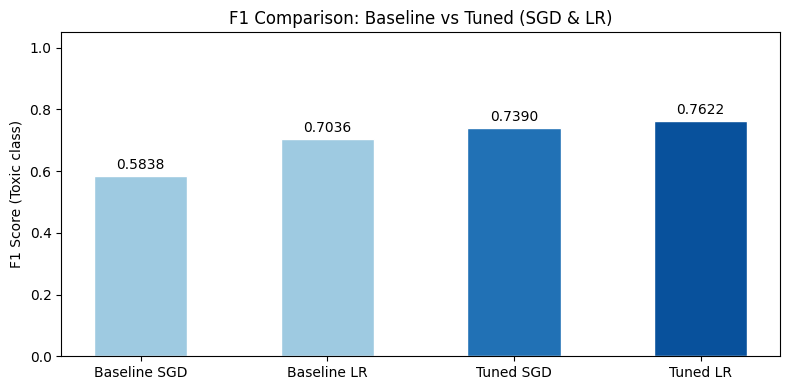

In [12]:
# Bar chart เปรียบเทียบ F1
names  = list(scores.keys())
f1s    = [scores[n]['f1'] for n in names]
colors = ['#9ecae1', '#9ecae1', '#2171b5', '#08519c']

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(names, f1s, color=colors, edgecolor='white', width=0.5)
ax.bar_label(bars, fmt='{:.4f}', padding=3, fontsize=10)
ax.set_ylim(0, 1.05)
ax.set_ylabel('F1 Score (Toxic class)')
ax.set_title('F1 Comparison: Baseline vs Tuned (SGD & LR)')
plt.tight_layout()
plt.show()

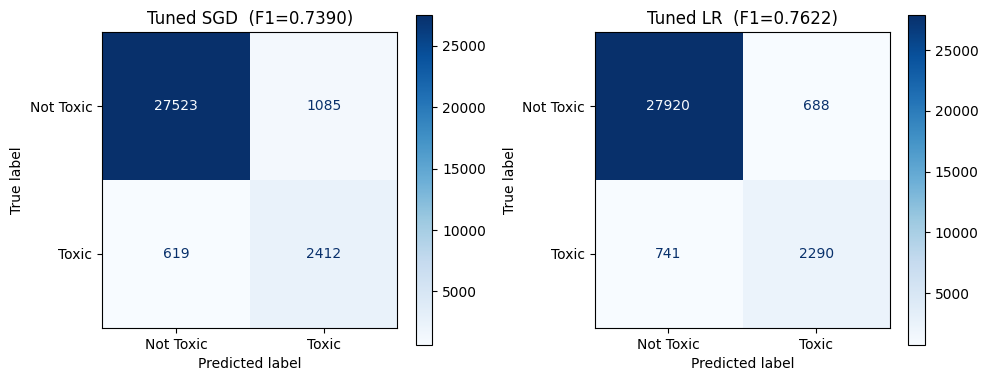

In [13]:
# Confusion Matrix ของ tuned models
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, name in zip(axes, ['Tuned SGD', 'Tuned LR']):
    ConfusionMatrixDisplay.from_predictions(
        y_test, scores[name]['pred'],
        display_labels=['Not Toxic', 'Toxic'],
        cmap='Blues', ax=ax
    )
    ax.set_title(f'{name}  (F1={scores[name]["f1"]:.4f})')
plt.tight_layout()
plt.show()

## Step 9: Save Best Model Overall

In [14]:
# Choose the best tuned model and save method-specific artifacts.
best_name = max(['Tuned SGD', 'Tuned LR'], key=lambda n: scores[n]['f1'])
best_model = models[best_name]

print(f'Best overall model : {best_name}')
print(f'Test F1            : {scores[best_name]["f1"]:.4f}')

with open(RANDOM_SEARCH_WORD_VECTORIZER_PATH, 'wb') as f:
    pickle.dump(word_vec, f)
with open(RANDOM_SEARCH_SCALER_PATH, 'wb') as f:
    pickle.dump(scaler, f)
with open(RANDOM_SEARCH_BEST_MODEL_PATH, 'wb') as f:
    pickle.dump(best_model, f)

print(f'Saved: {RANDOM_SEARCH_BEST_MODEL_PATH}')
print(f'Saved: {RANDOM_SEARCH_WORD_VECTORIZER_PATH} / {RANDOM_SEARCH_SCALER_PATH}')


Best overall model : Tuned LR
Test F1            : 0.7622
Saved: random_search_best_model.pkl
Saved: random_search_word_vectorizer.pkl / random_search_scaler.pkl


In [15]:
# Step 10: ทดสอบคำ / ประโยค
def predict_toxic(text, model, word_vec, scaler):
    raw = str(text)
    protected = protect_non_toxic_negations(raw)
    clean = clean_text(protected)

    X_word = word_vec.transform([clean])
    eng = build_all_engineered_features(raw)[ENG_FEATURE_COLS]
    X_eng = scaler.transform(eng.values)
    X = hstack([X_word, csr_matrix(X_eng)], format='csr')

    pred = model.predict(X)[0]
    prob = model.predict_proba(X)[0][1]
    label = 'TOXIC' if pred == 1 else 'NOT TOXIC'
    print(f'{label}  (confidence: {prob:.2%})')

# ── ใส่ประโยคที่ต้องการทดสอบได้เลย ──
predict_toxic("you are so stupid", best_model, word_vec, scaler)
predict_toxic("you are not stupid", best_model, word_vec, scaler)
predict_toxic("thank you for your help", best_model, word_vec, scaler)
predict_toxic("I disagree with your opinion", best_model, word_vec, scaler)


TOXIC  (confidence: 99.62%)
NOT TOXIC  (confidence: 35.12%)
NOT TOXIC  (confidence: 0.25%)
NOT TOXIC  (confidence: 7.58%)
